# Report: Work From Home Employee Burnout Analysis (Aggregated Metrics)

**Dataset:** Work From Home Employee Burnout Dataset (Kaggle)

**Data Scope:** 1800+ daily records

**Scope:** The goal of this analysis is to create a summarized, employee-level dataset (metrics_rel_data) to identify average behavioral patterns (work hours, screen time, sleep) and their direct relationship with, and impact on, task completion and burnout scores, rather than looking at daily fluctuations** The data focuses on daily behavioral patterns and their correlation with employee well-being

In [1]:
import pandas as pd
import numpy as np
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns
os.getcwd()
warnings.filterwarnings('ignore')

In [2]:
wfh = pd.read_csv("/kaggle/input/work-from-home-employee-burnout-dataset/work_from_home_burnout_dataset.csv")
wfh

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low
...,...,...,...,...,...,...,...,...,...,...,...
1795,180,Weekend,6.33,8.16,0,4,0,5.59,73.5,31.91,Low
1796,180,Weekend,4.70,7.88,0,4,0,6.69,89.8,26.30,Low
1797,180,Weekend,3.92,6.39,2,1,0,6.77,74.6,34.07,Low
1798,180,Weekday,8.93,11.11,2,5,0,8.28,74.6,38.14,Low


**DATA EXPLORATION**

In [3]:
wfh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   object 
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(4), object(2)
memory usage: 154.8+ KB


In [4]:
wfh.describe()     

,user_id,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,90.500000,6.515117,9.271406,1.941111,3.028889,0.358889,6.996467,72.308556,44.009978
std,51.975162,2.290521,2.409253,1.696178,1.417844,0.479808,1.061740,14.978647,23.881782
min,1.000000,3.000000,4.510000,0.000000,1.000000,0.000000,4.500000,40.000000,2.500000
25%,45.750000,4.430000,7.240000,1.000000,2.000000,0.000000,6.280000,62.300000,25.370000
50%,90.500000,6.445000,9.210000,2.000000,3.000000,0.000000,6.990000,74.500000,39.270000
75%,135.250000,8.510000,11.310000,3.000000,4.000000,1.000000,7.750000,83.700000,58.197500
max,180.000000,12.170000,15.700000,10.000000,5.000000,1.000000,10.800000,107.200000,143.920000


In [5]:
wfh = wfh.astype({'screen_time_hours': int,'sleep_hours': int,'task_completion_rate': int,'burnout_score':int})    # changed the data type as decimal points are not carrying any value
wfh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   object 
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   int64  
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   int64  
 8   task_completion_rate  1800 non-null   int64  
 9   burnout_score         1800 non-null   int64  
 10  burnout_risk          1800 non-null   object 
dtypes: float64(1), int64(8), object(2)
memory usage: 154.8+ KB


In [6]:
wfh.isnull().sum()

user_id                 0
day_type                0
work_hours              0
screen_time_hours       0
meetings_count          0
breaks_taken            0
after_hours_work        0
sleep_hours             0
task_completion_rate    0
burnout_score           0
burnout_risk            0
dtype: int64

In [7]:
wfh['extra_hr'] = wfh['work_hours'].apply(lambda x: x-8 if x>8 else 0 )    # created a column of extra hour where employees working for more than 8 hrs
wfh.head()


,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk,extra_hr
0,1,Weekday,9.59,11,4,2,0,7,91,19,Low,1.59
1,1,Weekend,7.38,10,4,1,0,6,82,29,Low,0.00
2,1,Weekend,6.31,8,1,2,0,8,80,32,Low,0.00
3,1,Weekday,8.34,10,4,1,1,8,70,45,Low,0.34
4,1,Weekend,6.97,9,1,2,0,5,67,51,Low,0.00


In [8]:
wfh['burnout_risk'].value_counts()       

burnout_risk
Low       1527
Medium     253
High        20
Name: count, dtype: int64

In [9]:
risk_analysis = wfh.groupby('day_type')['burnout_score'].agg(['mean','max','count'])
risk_analysis

,mean,max,count
day_type,,,
Weekday,46.335616,143,876
Weekend,40.837662,129,924


**Burnout Risk As Per Weekdays & Weekends Working Hours**

In [10]:
weekdays_risk= wfh.groupby('day_type')['burnout_risk'].value_counts()
weekdays_risk

day_type  burnout_risk
Weekday   Low             724
          Medium          137
          High             15
Weekend   Low             803
          Medium          116
          High              5
Name: count, dtype: int64

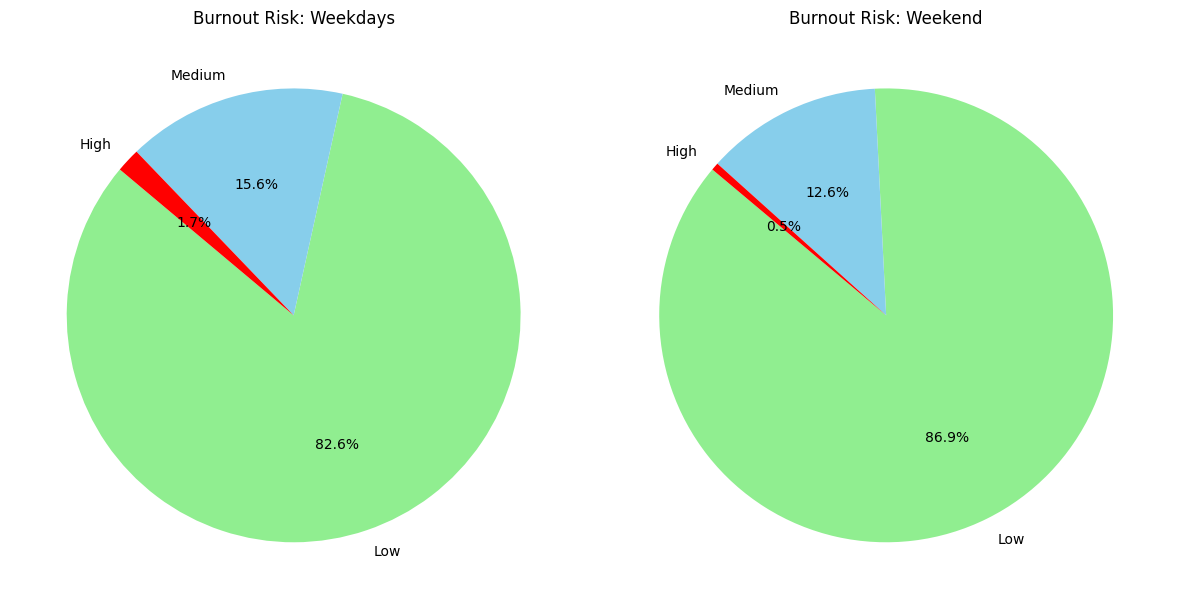

In [11]:
weekday_data = weekdays_risk['Weekday']  # isolate data for each day type
weekend_data = weekdays_risk['Weekend']
# create a sub plot of two fig
fig, (ax1,ax2)=plt.subplots(1,2, figsize = (12,6))
ax1.pie(weekday_data, labels = weekday_data.index, autopct='%1.1f%%', startangle =140, colors = ['lightgreen','skyblue','red'])
ax1.set_title("Burnout Risk: Weekdays")
ax2.pie(weekend_data, labels = weekend_data.index, autopct='%1.1f%%', startangle =140, colors = ['lightgreen','skyblue','red'])
ax2.set_title("Burnout Risk: Weekend")
plt.tight_layout()
plt.show()

We can infer that in both the category majority of emloyees are at low risk. Employees working on weekends too are at burnout risk

In [12]:
df = pd.DataFrame({'user_id': wfh['user_id'].values,
                  "day_type": wfh['day_type'].values,
                  'work_hours': wfh['work_hours']})
df
result = df.pivot_table(index = 'user_id', columns = 'day_type', values = 'work_hours', aggfunc = 'sum', fill_value = 0)
result

day_type,Weekday,Weekend
user_id,,
1,49.13,26.59
2,31.32,22.65
3,41.34,23.66
4,27.68,33.57
5,36.56,28.10
...,...,...
176,37.66,24.95
177,50.67,17.20
178,32.57,26.05


**Relaion Between Screentime Hours And Burnout Score**

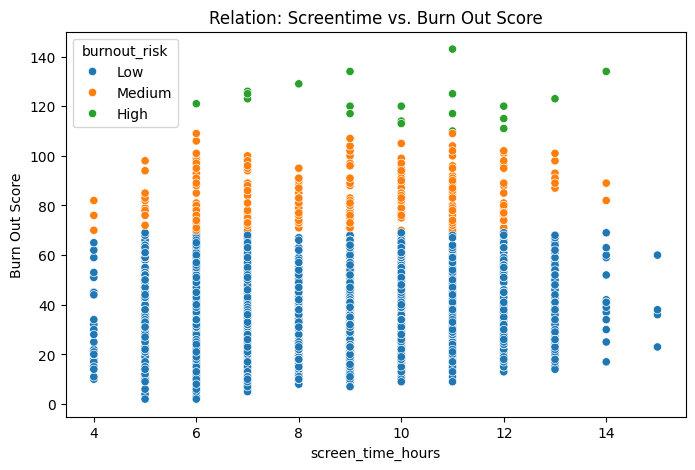

In [13]:
plt.figure(figsize = (8,5))
sns.scatterplot(data = wfh, x = 'screen_time_hours', y= 'burnout_score', hue = 'burnout_risk')
plt.title('Relation: Screentime vs. Burn Out Score')
plt.ylabel('Burn Out Score')
plt.show()

**There is a positive correlaion  between Screentime hours and burnout score.  As the number of Screentime hours is increases (moving right on the X-axis) the burn out score generally increases (moving up on the Y-axis)**

**Task Completion Rate V/s Burnout Score**

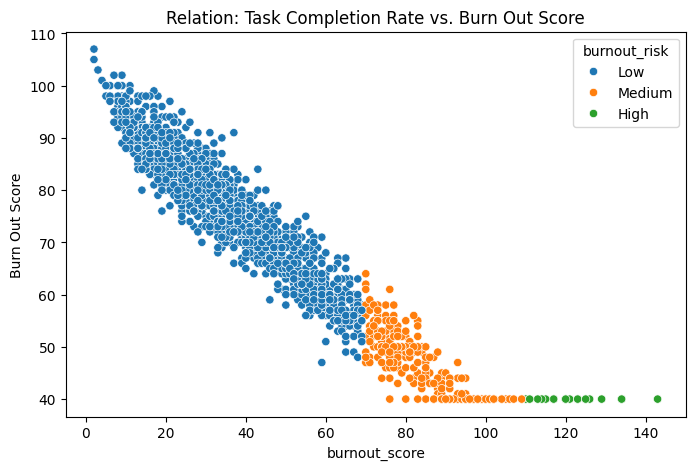

In [14]:
plt.figure(figsize = (8,5))
sns.scatterplot(data = wfh, x = 'burnout_score', y= 'task_completion_rate', hue = 'burnout_risk')
plt.title('Relation: Task Completion Rate vs. Burn Out Score')
plt.ylabel('Burn Out Score')
plt.show()

**Impact Of Working Hours, Screen Time, Breaks, Meetings Task Completion are having negative impact on employees**

In [15]:
wfh = pd.read_csv("/kaggle/input/work-from-home-employee-burnout-dataset/work_from_home_burnout_dataset.csv")
relevant_data = wfh[['user_id','work_hours','screen_time_hours','sleep_hours','task_completion_rate','burnout_score']]
metrics_rel_data = relevant_data.groupby('user_id').mean()
print(metrics_rel_data)


         work_hours  screen_time_hours  sleep_hours  task_completion_rate  \
user_id                                                                     
1             7.572             10.332        6.962                 67.07   
2             5.397              7.902        6.861                 83.96   
3             6.500              9.423        6.744                 86.40   
4             6.125              8.978        7.304                 77.79   
5             6.466              9.032        6.969                 77.83   
...             ...                ...          ...                   ...   
176           6.261              8.937        6.924                 67.08   
177           6.787              9.525        7.000                 73.67   
178           5.862              8.307        6.557                 64.23   
179           5.430              8.356        6.802                 79.54   
180           5.352              8.212        6.918                 80.91   

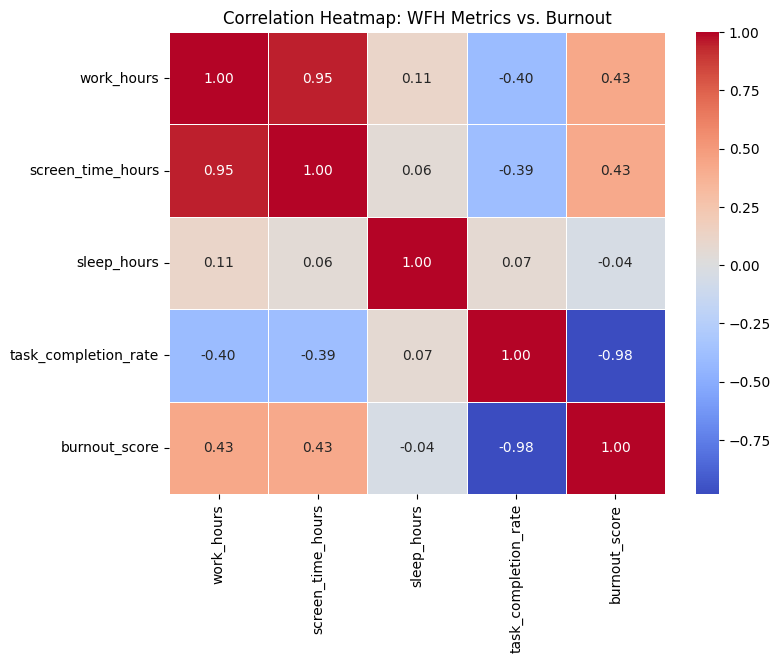

In [16]:
corr_matrix = metrics_rel_data.corr()

# 2. Set up the figure size
plt.figure(figsize=(8,6))

# 3. Create the heatmap
sns.heatmap(corr_matrix, 
            annot=True,          # Show the correlation values in each cell
            cmap='coolwarm',     # Red for positive correlation, blue for negative
            fmt=".2f",           # Limit to 2 decimal places
            linewidths=0.5)      # Add slight spacing between cells

plt.title('Correlation Heatmap: WFH Metrics vs. Burnout')
plt.show()

**What to Look For in Your Heatmap**

**Strong Positive Correlations (Dark Red):** If screen_time_hours and burnout_score have a high positive value (e.g., > 0.6), it confirms that digital fatigue is a primary burnout driver.

**Strong Negative Correlations (Dark Blue):** Typically, sleep_hours will have a negative correlation with burnout_score, meaning as sleep increases, burnout tends to decrease.

**Performance Insight:** Check the link between task_completion_rate and work_hours. If the correlation is low, it suggests that working longer hours isn't necessarily making employees more productive.

Work & Screen Time (work_hours, screen_time_hours): These metrics quantify the daily workload and digital exposure. Higher averages here are typically correlated with increased "Mental Fatigue" and higher burnout rates.
Rest (sleep_hours): This serves as a critical well-being indicator. Data often shows that deterioration in sleep (e.g., trouble falling or staying asleep) is one of the most significant health challenges associated with the transition to WFH.
Performance (task_completion_rate): Measures productivity by calculating the percentage of planned tasks finished. This helps determine if high "Work Hours" actually result in high output or if burnout is causing diminishing returns.
Burnout Intensity (burnout_score): A continuous variable where a higher score indicates greater exhaustion and stress.


**The code provides a clean, aggregated overview of employee burnout. It effectively summarizes daily data, allowing for identifying trends in working hours, sleep habits, and burnout, which is crucial for organizations looking to optimize remote work environments and protect employee mental health**